In [10]:
import numpy as np
import matplotlib.pyplot as plt

$\textbf{Exercise 3}$

$\textbf{a)}$

Equations get unstable when denominator gets close to zero. So for this equation when 

$1-ß^2 cos^2 \theta$ = 0
<-> 1= $ß^2 \text{cos}^2 \theta$ 

with ß=$\sqrt{1-\gamma^{-2}} = \sqrt{1-\frac{E}{m}^{-2}}$
 $=\sqrt{1-\frac{75*10^9}{511*10^3}^{-2}}$


$1/ß^2= \text{cos}^2 \theta$

$arccos(1/ß^2) =\theta$

also ß always equal or smaller 1

In [12]:
#given numbers
E = 75.0 *10**9             
m = 511*10**3          

# define lorentzfactor and beta**2
gamma = E / m
beta_squared = (1 - 1/gamma**2)


# use (0 to pi)
theta = np.linspace(0, np.pi, 1_000_000)

# calculate denominator
denominator = 1 - beta_squared * np.cos(theta)**2

# set a threshold for values that are small enough to create issues
threshold = 1e-10

# find indices where it gets critical 
unstable_indices = np.where(denominator < threshold)[0]

# get values for theta from those indices
unstable_theta = theta[unstable_indices]

if len(unstable_theta) > 0:
    print(f"Min θ: {unstable_theta.min():.3e} rad")
    print(f"Max θ: {unstable_theta.max():.3e} rad")


Min θ: 0.000e+00 rad
Max θ: 3.142e+00 rad


We see it get unstable for $\theta$ close to 0 or $\pi$, so lets print the actual denominator values for that to check if it gets small for cos($\theta=0$ or $\theta=\pi$)=1

In [9]:
print(1-beta_squared)

4.6421533284046745e-11


denominator = 4.6 $\cdot 10^{-11}$ is numerically small so it makes sense that this will create unstability

$\textbf{Answer:}$ for $\theta$ close to 0 or $\pi$.

$\textbf{b)}$

work on denominator:

$1- \beta^2 \text{cos}^2(\theta) $

$= 1- \beta^2 + \beta^2 - \beta^2\text{cos}^2(\theta)$  |adding and subtracting $\beta^2$ here

$= (1 - \beta^2) + \beta^2 (1-\text{cos}^2(\theta))$

with $(1 - \beta^2) = \frac{1}{\gamma^2}$ and $1= \text{sin}^2(\theta)+\text{cos}^2(\theta)$ <-> $(1-\text{cos}^2(\theta)) = \text{sin}^2(\theta)$

follows

denominator = $\frac{1}{\gamma^2} + \beta^2 \text{sin}^2(\theta)$

$\textbf{Final stable equation:}$ $f(E,\theta)=\frac{2+ \text{sin}^2(\theta)} {\frac{1}{\gamma^2} + \beta^2 \text{sin}^2(\theta)}$




$\textbf{c)}$

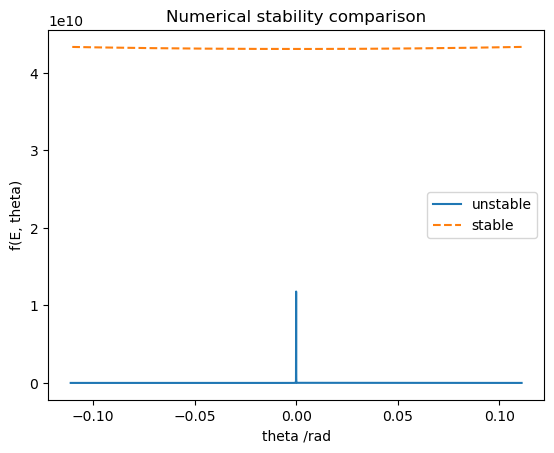

In [24]:
# critical interval (chose the one around 0, it is the same for around pi)
theta = np.linspace(0.111, -0.111, 10000)

# unchanged f (unstable)
f_unstable = (2 + np.sin(theta)**2) / (1 - beta_squared * np.cos(theta)**2)

# stable f
f_stable = (2 + np.sin(theta)**2) / (1/gamma**2) + (beta_squared * np.sin(theta)**2)

# plot
plt.figure()
plt.plot(theta, f_unstable, label="unstable")
plt.plot(theta, f_stable, '--', label="stable")
plt.xlabel("theta /rad")
plt.ylabel("f(E, theta)")
plt.title("Numerical stability comparison")
plt.legend()
#plt.yscale("log") (tried log-scale but think without is better)
plt.show()

$\textbf{d)}$

Condition numer is defined as $K=|x \frac{f`(x)}{f(x)}|$ here with $x=\theta$

$\tilde{\theta} = \theta(1+\varepsilon)$       ( small relative error $\varepsilon$)

$\textbf{Taylor expansion:}$

$f(\tilde{\theta}) = f(\theta + \varepsilon \theta)
= f(\theta) + \varepsilon \theta f'(\theta) + \mathcal{O}(\varepsilon^2)$

$\textbf{Relative error:}$

$|\frac{f(\tilde{\theta}) - f(\theta)}{f(\theta)}| = |\frac{\theta f'(\theta)}{f(\theta)}| \cdot |\varepsilon|+ \text{O}(\varepsilon^2)$

$\textbf{Condition number:}$

$K(\theta) = \left|\frac{\theta f'(\theta)}{f(\theta)}\right|$


quotient rule for derivitive: $f'(\theta) = \frac{N'D - ND'}{D^2}$

Nominator =$ 2 + \text{sin}^2(\theta)$  --> $N' = 2\sin\theta \cos\theta$

Denominator = $1 - \beta^2 \text{cos}^2(\theta)$ -->  $D' = 2\beta^2 \cos\theta \sin\theta$


$f'(\theta) = \frac{2\sin\theta\cos\theta \cdot D - (2+\sin^2\theta)\cdot 2\beta^2 \cos\theta \sin\theta}{D^2}$

=$\frac{2\sin\theta\cos\theta}{D^2} \left[ D - \beta^2 (2+\sin^2\theta) \right]$

with $f = \frac{N}{D}$

$\frac{f'(\theta)}{f(\theta)} = \frac{f'(\theta) D}{N}$

$K(\theta) =\left|\theta \cdot\frac{2\sin\theta\cos\theta}{D}\cdot\frac{D - \beta^2(2+\sin^2\theta)}{2+\sin^2\theta}\right|$

$\textbf{Asymptotic behaviour for small angles:}$

For $\theta \ll 1$:

$\sin\theta \approx \theta, \quad \cos\theta \approx 1$

and using

$1 - \beta^2 = \frac{1}{\gamma^2}$

$D \approx \frac{1}{\gamma^2} + \beta^2 \theta^2$

behaviour of the condition number is:

$K(\theta) \sim\frac{2 \theta^2 \beta^2}{\frac{1}{\gamma^2} + \beta^2 \theta^2}$




-For $\theta \ll 1/\gamma$: $K(\theta) \ll 1$ (well-conditioned)

-For $\theta \sim 1/\gamma$: $K(\theta) \sim \mathcal{O}(1)$

-For $\theta \gg 1/\gamma$: $K(\theta) \to 2$


Thus, the function is well-conditioned for all $\theta$.  
The numerical instability observed for small $\theta$ originates from cancellation in the denominator rather than poor conditioning.


$\textbf{e)}$

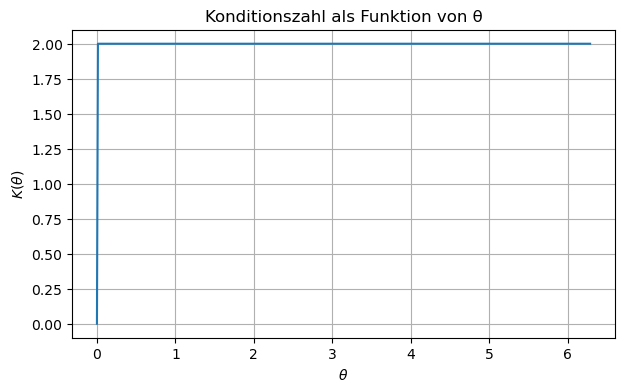

In [26]:


# theta Werte von 0 bis pi
theta = np.linspace(0, 2*np.pi, 500)

# Konditionszahl
K = (2 * theta**2 * beta_squared) / (1/gamma**2 + beta_squared * theta**2)

# Plot
plt.figure(figsize=(7,4))
plt.plot(theta, K)

plt.xlabel(r'$\theta$')
plt.ylabel(r'$K(\theta)$')
plt.title('Konditionszahl als Funktion von θ')
plt.grid(True)

plt.show()






$\textbf{f)}$

Condition measures how sensitive the output is to small changes or errors in the input data.
A problem is well-conditioned if small input changes lead to small output changes, and ill-conditioned if small input changes can cause large output changes.
Stability describes how errors (especially rounding or numerical errors during computation) are amplified or controlled during the calculation process.
A method is stable if it does not significantly amplify errors, and unstable if errors grow during computation.